# Données Google Earth Engine

`Gee` donne accès au catalogue Earth Engine (Sentinel-1/2, Landsat-9,
MODIS…) : recherche d'images, masquage nuageux, NDVI, statistiques
zonales, téléchargement GeoTIFF et carte interactive.

## Prérequis

1. **Authentification unique** (une fois par machine) :
   ```bash
   earthengine authenticate
   ```
   ou, en Python : `import ee; ee.Authenticate()`.
2. **ID de projet GCP** : `Gee` le lit depuis la variable d'environnement
   `GEE_PROJECT`. On la charge ici depuis un fichier **`.env`** à la racine
   du dépôt (non versionné) contenant :
   ```
   GEE_PROJECT=ee-kanicetcyrille
   ```

In [1]:
import logging
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # cartograpy est à la racine du dépôt
logging.basicConfig(level=logging.INFO, format="%(message)s")

from dotenv import load_dotenv

load_dotenv(Path.cwd().parent / ".env")   # racine du dépôt
load_dotenv()                              # ou un .env dans notebooks/
print("GEE_PROJECT =", os.environ.get("GEE_PROJECT"))

GEE_PROJECT = ee-kanicetcyrille


In [2]:
import cartograpy as cp
from cartograpy.data import Gee

gee = Gee()          # projet pris dans GEE_PROJECT
gee

C:\Users\Ordinateur\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\metadata\__init__.py:467: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  return self.metadata['Version']


✅ Google Earth Engine initialisé avec succès.


Gee(project='ee-kanicetcyrille')

## Zone et période d'étude

Une petite emprise autour de **Yamoussoukro** ; bbox `[xmin, ymin, xmax, ymax]`.

In [3]:
BBOX = [-5.31, 6.78, -5.20, 6.88]
START, END = "2024-01-01", "2024-03-31"  # saison sèche = peu de nuages

## Sentinel-2 : mosaïque médiane sans nuages

In [4]:
s2 = gee.get_sentinel2(BBOX, START, END, cloud=0.2)
print("images dans la collection :", gee.count())

📡 Sentinel-2 : 7 image(s) trouvée(s) [2024-01-01 → 2024-03-31]
images dans la collection : 7


## NDVI et statistiques zonales

`compute_ndvi` ajoute une bande NDVI (NIR=B8, Rouge=B4). `zonal_stats`
réduit l'image sur la bbox.

In [5]:
ndvi = gee.compute_ndvi(s2)

stats = gee.zonal_stats(ndvi, BBOX, scale=10, reducer="mean")
{k: round(v, 4) for k, v in stats.items() if v is not None}

{'B2': 0.0558, 'B3': 0.0855, 'B4': 0.1001, 'B8': 0.2379, 'NDVI': 0.4198}

## N'importe quelle collection

`collection()` accepte un identifiant GEE quelconque avec des filtres
optionnels — ici le NDVI MODIS 16 jours.

In [6]:
modis = gee.collection("MODIS/061/MOD13A2", bbox=BBOX, start="2024-01-01", end="2024-04-01")
gee.dates(modis)

📂 Collection «MODIS/061/MOD13A2» : 6 image(s)


c:\Users\Ordinateur\OneDrive\cartograpy\cartograpy\data\gee.py:357: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  datetime.datetime.utcfromtimestamp(d / 1000).strftime("%Y-%m-%d")
c:\Users\Ordinateur\OneDrive\cartograpy\cartograpy\data\gee.py:357: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  datetime.datetime.utcfromtimestamp(d / 1000).strftime("%Y-%m-%d")
c:\Users\Ordinateur\OneDrive\cartograpy\cartograpy\data\gee.py:357: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetim

['2024-01-01',
 '2024-01-17',
 '2024-02-02',
 '2024-02-18',
 '2024-03-05',
 '2024-03-21']

## Télécharger un GeoTIFF

`download` exporte l'image (ou la médiane d'une collection) via `geemap`.

In [7]:
tif = gee.download(
    ndvi,
    bbox=BBOX,
    filename="yamoussoukro_ndvi.tif",
    bands=["NDVI"],
    scale=20,
    output_dir="_gee_cache",
)
tif

⬇️  Téléchargement vers «_gee_cache\yamoussoukro_ndvi.tif» (scale=20m, crs=EPSG:4326)…
Generating URL ...
Please wait ...
Data downloaded to c:\Users\Ordinateur\OneDrive\cartograpy\notebooks\_gee_cache\yamoussoukro_ndvi.tif
✅ Fichier sauvegardé : _gee_cache\yamoussoukro_ndvi.tif


WindowsPath('_gee_cache/yamoussoukro_ndvi.tif')

dimensions : 613 x 557 | CRS : EPSG:4326


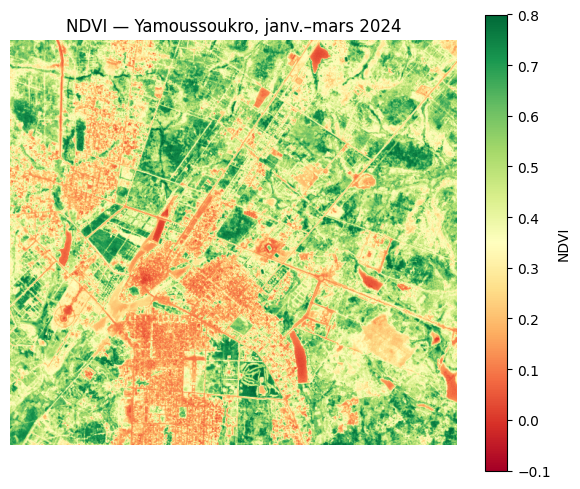

In [8]:
import matplotlib.pyplot as plt
import rasterio

with rasterio.open(tif) as src:
    arr = src.read(1)
    print("dimensions :", src.width, "x", src.height, "| CRS :", src.crs)

plt.figure(figsize=(6, 6))
im = plt.imshow(arr, cmap="RdYlGn", vmin=-0.1, vmax=0.8)
plt.colorbar(im, shrink=0.8, label="NDVI")
plt.title("NDVI — Yamoussoukro, janv.–mars 2024")
plt.axis("off")
plt.tight_layout()

# Autres jeux de données

Au-delà du NDVI, `download` récupère n'importe quelles bandes d'une image ou
d'une collection GEE : composés optiques, radar, cartes d'occupation du sol…

## Sentinel-2 en vraies couleurs

Mêmes images que plus haut, mais on exporte les bandes RGB (`B4`, `B3`, `B2`).

⬇️  Téléchargement vers «_gee_cache\yamoussoukro_s2_rgb.tif» (scale=20m, crs=EPSG:4326)…
Generating URL ...
Please wait ...
Data downloaded to c:\Users\Ordinateur\OneDrive\cartograpy\notebooks\_gee_cache\yamoussoukro_s2_rgb.tif
✅ Fichier sauvegardé : _gee_cache\yamoussoukro_s2_rgb.tif


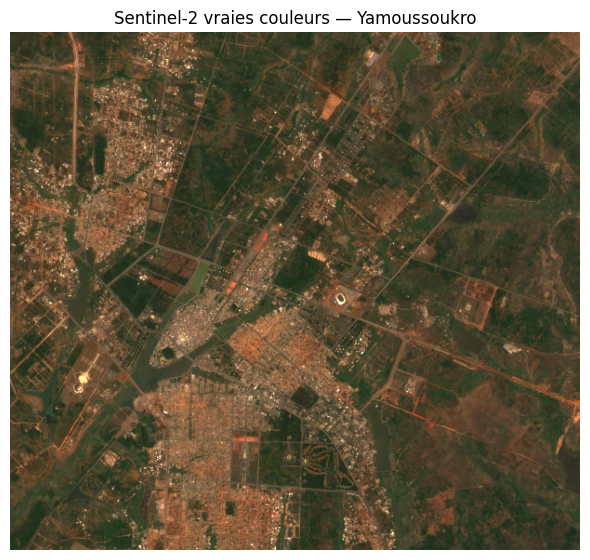

In [9]:
import numpy as np

s2_rgb = gee.download(
    s2, bbox=BBOX, filename="yamoussoukro_s2_rgb.tif",
    bands=["B4", "B3", "B2"], scale=20, output_dir="_gee_cache",
)

with rasterio.open(s2_rgb) as src:
    rgb = np.dstack([src.read(i) for i in (1, 2, 3)])

plt.figure(figsize=(6, 6))
plt.imshow(np.clip(rgb / 0.3, 0, 1))   # réflectances 0–1 après masquage → étirées à 0–0.3
plt.title("Sentinel-2 vraies couleurs — Yamoussoukro")
plt.axis("off")
plt.tight_layout()

## Landsat-9

`get_landsat9` fonctionne comme `get_sentinel2` (collection
`LANDSAT/LC09/C02/T1_L2`, ~30 m, masque nuageux `QA_PIXEL`, réflectances
mises à l'échelle). Bandes RGB : `SR_B4`, `SR_B3`, `SR_B2`.

🛰️  Landsat-9 : 13 image(s) trouvée(s) [2023-11-01 → 2024-04-01]
⬇️  Téléchargement vers «_gee_cache\yamoussoukro_l9_rgb.tif» (scale=30m, crs=EPSG:4326)…
Generating URL ...
Please wait ...
Data downloaded to c:\Users\Ordinateur\OneDrive\cartograpy\notebooks\_gee_cache\yamoussoukro_l9_rgb.tif
✅ Fichier sauvegardé : _gee_cache\yamoussoukro_l9_rgb.tif


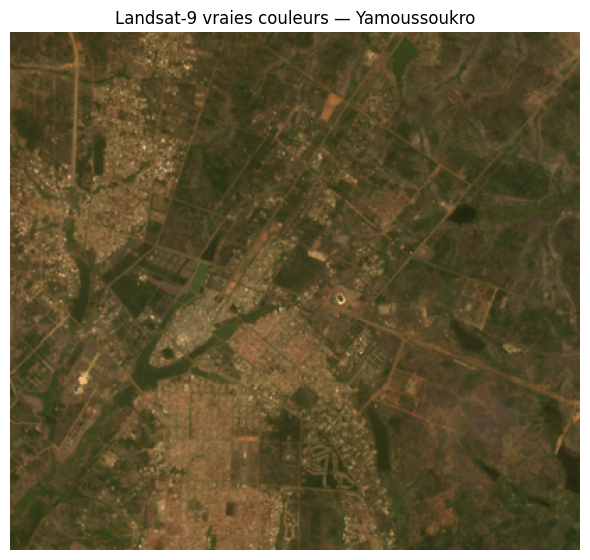

In [10]:
l9 = gee.get_landsat9(BBOX, "2023-11-01", "2024-04-01", cloud=0.3)

l9_rgb = gee.download(
    l9, bbox=BBOX, filename="yamoussoukro_l9_rgb.tif",
    bands=["SR_B4", "SR_B3", "SR_B2"], scale=30, output_dir="_gee_cache",
)

with rasterio.open(l9_rgb) as src:
    rgb = np.dstack([src.read(i) for i in (1, 2, 3)])

plt.figure(figsize=(6, 6))
plt.imshow(np.clip(rgb / 0.3, 0, 1))
plt.title("Landsat-9 vraies couleurs — Yamoussoukro")
plt.axis("off")
plt.tight_layout()

## Sentinel-1 (radar SAR)

`get_sentinel1` filtre la collection `COPERNICUS/S1_GRD` (mode IW) et
renvoie une mosaïque moyenne. Les valeurs sont en décibels.

📻 Sentinel-1 : 8 image(s) trouvée(s) [2024-01-01 → 2024-03-31]
⬇️  Téléchargement vers «_gee_cache\yamoussoukro_s1_vv.tif» (scale=20m, crs=EPSG:4326)…
Generating URL ...
Please wait ...
Data downloaded to c:\Users\Ordinateur\OneDrive\cartograpy\notebooks\_gee_cache\yamoussoukro_s1_vv.tif
✅ Fichier sauvegardé : _gee_cache\yamoussoukro_s1_vv.tif


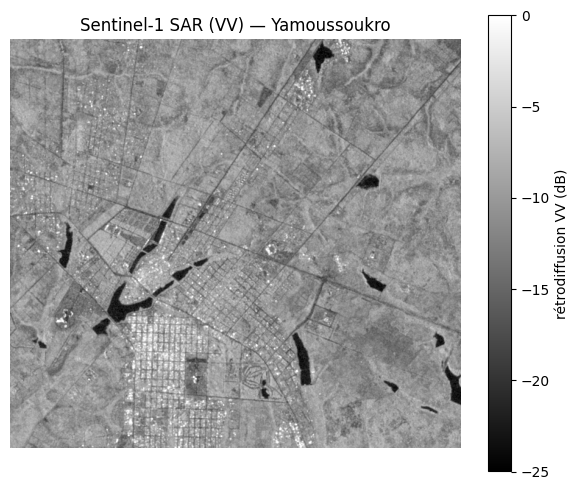

In [11]:
# Sur cette zone, seules des orbites ASCENDING sont disponibles
s1 = gee.get_sentinel1(BBOX, START, END, polarization="VV", pass_direction="ASCENDING")

s1_tif = gee.download(
    s1, bbox=BBOX, filename="yamoussoukro_s1_vv.tif",
    bands=["VV"], scale=20, output_dir="_gee_cache",
)

with rasterio.open(s1_tif) as src:
    vv = src.read(1)

plt.figure(figsize=(6, 6))
im = plt.imshow(vv, cmap="gray", vmin=-25, vmax=0)
plt.colorbar(im, shrink=0.8, label="rétrodiffusion VV (dB)")
plt.title("Sentinel-1 SAR (VV) — Yamoussoukro")
plt.axis("off")
plt.tight_layout()

## Occupation du sol — ESRI Land Cover 10 m

`collection()` accepte aussi les jeux communautaires. `projects/sat-io/open-datasets/landcover/ESRI_Global-LULC_10m_TS`
est la série annuelle ESRI (band `b1`). Comme c'est une donnée catégorielle,
on prend `.mosaic()` (et non une médiane).

📂 Collection «projects/sat-io/open-datasets/landcover/ESRI_Global-LULC_10m_TS» : 1 image(s)
⬇️  Téléchargement vers «_gee_cache\yamoussoukro_esri_lulc.tif» (scale=10m, crs=EPSG:4326)…
Generating URL ...
Please wait ...
Data downloaded to c:\Users\Ordinateur\OneDrive\cartograpy\notebooks\_gee_cache\yamoussoukro_esri_lulc.tif
✅ Fichier sauvegardé : _gee_cache\yamoussoukro_esri_lulc.tif


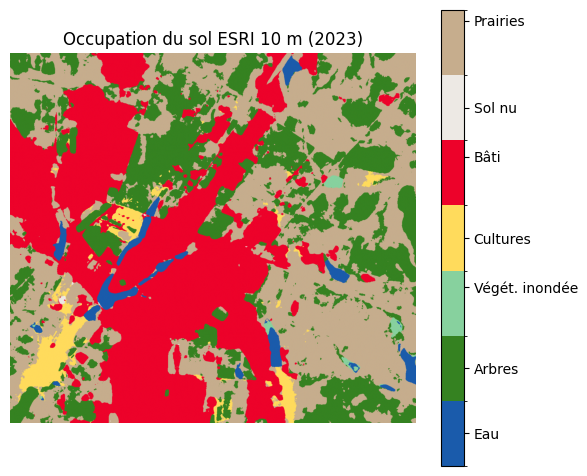

In [12]:
from matplotlib.colors import ListedColormap, BoundaryNorm

esri = gee.collection(
    "projects/sat-io/open-datasets/landcover/ESRI_Global-LULC_10m_TS",
    bbox=BBOX, start="2023-01-01", end="2024-01-01",
).mosaic()

esri_tif = gee.download(
    esri, bbox=BBOX, filename="yamoussoukro_esri_lulc.tif",
    bands=["b1"], scale=10, output_dir="_gee_cache",
)

ESRI_CLASSES = {1: "Eau", 2: "Arbres", 4: "Végét. inondée", 5: "Cultures",
                7: "Bâti", 8: "Sol nu", 9: "Neige/glace", 10: "Nuages", 11: "Prairies"}
ESRI_COLORS = {1: "#1A5BAB", 2: "#358221", 4: "#87D19E", 5: "#FFDB5C", 7: "#ED022A",
               8: "#EDE9E4", 9: "#F2FAFF", 10: "#C8C8C8", 11: "#C6AD8D"}

with rasterio.open(esri_tif) as src:
    lulc = src.read(1)

vals = sorted(v for v in ESRI_CLASSES if (lulc == v).any())
cmap = ListedColormap([ESRI_COLORS[v] for v in vals])
norm = BoundaryNorm([vals[0] - 0.5] + [v + 0.5 for v in vals], cmap.N)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(lulc, cmap=cmap, norm=norm)
cbar = fig.colorbar(im, ax=ax, shrink=0.8, ticks=vals)
cbar.ax.set_yticklabels([ESRI_CLASSES[v] for v in vals])
ax.set_title("Occupation du sol ESRI 10 m (2023)")
ax.axis("off")
fig.tight_layout()

## Occupation du sol — Dynamic World

`GOOGLE/DYNAMICWORLD/V1` : classification quasi temps réel à 10 m dérivée de
Sentinel-2. Bande `label` (0–8) = classe la plus probable ; 9 bandes de
probabilité en plus. On agrège la période par la classe majoritaire (`mode`).

📂 Collection «GOOGLE/DYNAMICWORLD/V1» : 31 image(s)
⬇️  Téléchargement vers «_gee_cache\yamoussoukro_dynamicworld.tif» (scale=10m, crs=EPSG:4326)…
Generating URL ...
Please wait ...
Data downloaded to c:\Users\Ordinateur\OneDrive\cartograpy\notebooks\_gee_cache\yamoussoukro_dynamicworld.tif
✅ Fichier sauvegardé : _gee_cache\yamoussoukro_dynamicworld.tif


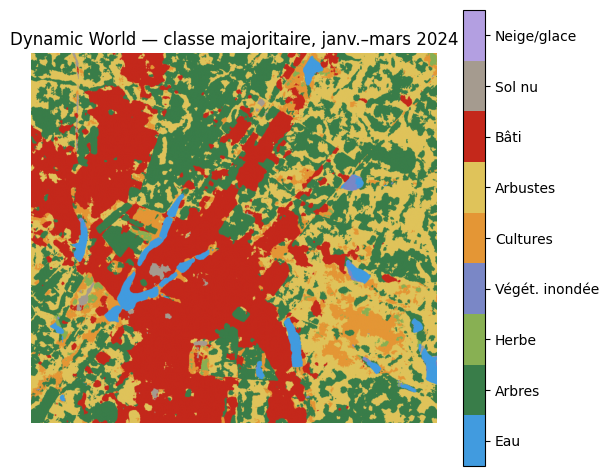

In [13]:
import ee
from matplotlib.colors import ListedColormap

# classe majoritaire sur la période (near-real-time, 10 m, 9 classes)
dw = gee.collection("GOOGLE/DYNAMICWORLD/V1", bbox=BBOX, start=START, end=END)
dw_label = dw.select("label").reduce(ee.Reducer.mode()).rename("label")

dw_tif = gee.download(
    dw_label, bbox=BBOX, filename="yamoussoukro_dynamicworld.tif",
    bands=["label"], scale=10, output_dir="_gee_cache",
)

DW_CLASSES = ["Eau", "Arbres", "Herbe", "Végét. inondée", "Cultures",
              "Arbustes", "Bâti", "Sol nu", "Neige/glace"]
DW_COLORS = ["#419BDF", "#397D49", "#88B053", "#7A87C6", "#E49635",
             "#DFC35A", "#C4281B", "#A59B8F", "#B39FE1"]

with rasterio.open(dw_tif) as src:
    lab = src.read(1)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(lab, cmap=ListedColormap(DW_COLORS), vmin=-0.5, vmax=8.5)
cbar = fig.colorbar(im, ax=ax, shrink=0.8, ticks=range(9))
cbar.ax.set_yticklabels(DW_CLASSES)
ax.set_title("Dynamic World — classe majoritaire, janv.–mars 2024")
ax.axis("off")
fig.tight_layout()

## Carte interactive geemap

`show_map` renvoie une carte `geemap` (tuiles GEE côté serveur). Après le
masquage nuageux les réflectances Sentinel-2 sont ramenées en 0–1, d'où le
`max` de visualisation à 0,3.

In [14]:
vis = {"bands": ["B4", "B3", "B2"], "min": 0, "max": 0.3}
carte = gee.show_map(s2, bbox=BBOX, vis_params=vis, name="Sentinel-2")
carte.addLayer(ndvi.select("NDVI"), {"min": -0.1, "max": 0.8, "palette": ["white", "green"]}, "NDVI")
carte

🗺️  Layer «Sentinel-2» ajouté à la carte.


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

## Grandes emprises : export vers Google Drive

Au-delà de ~50 Mpx, `download` échoue. Pour une région entière, lancer une
tâche asynchrone :

```python
gee.export_to_drive(ndvi, bbox=BBOX, description="ndvi_civ", folder="GEE_exports", scale=10)
# suivi : import ee; ee.batch.Task.list()
```